Mean JSD over 1598 sequences: 0.147060


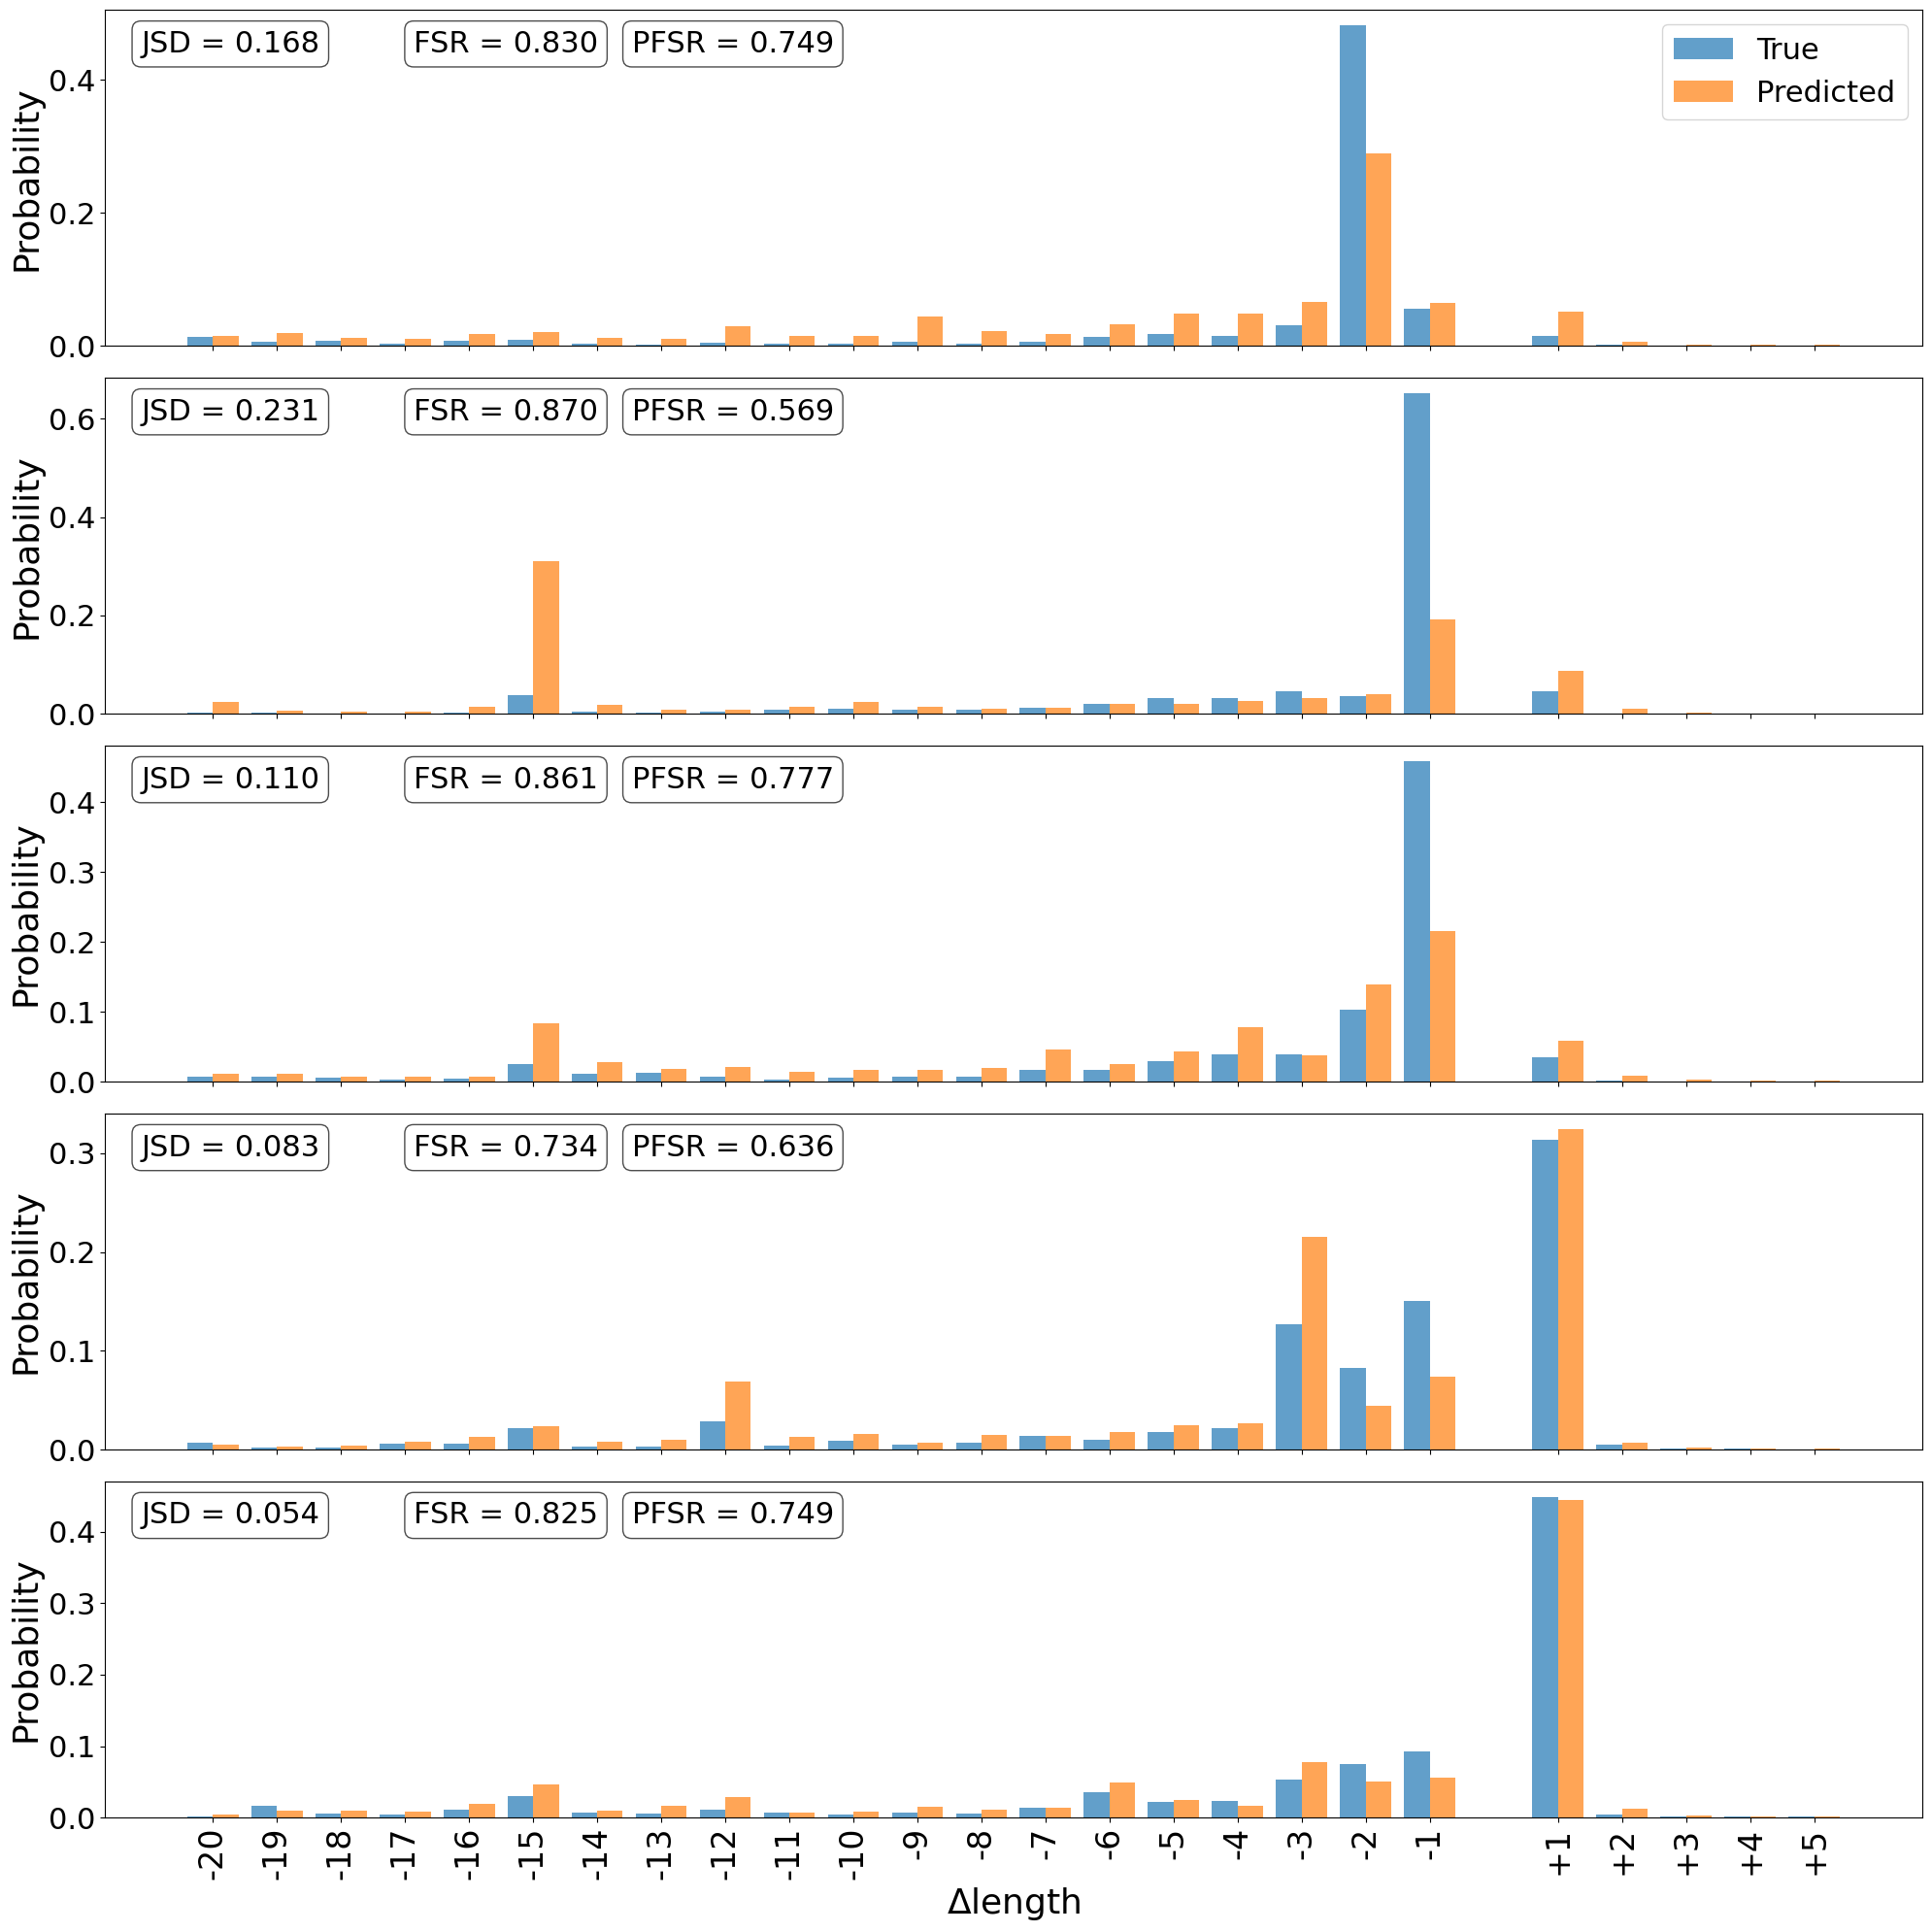

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the FORECasT K562 outcomes table
csv_path = "ADL/FORECasT_K562_outcomes.csv"
df = pd.read_csv(csv_path)

# Use overlapping positions that have both true counts and predicted (delta_) columns
positions = list(range(-70, 21))
orig_cols = [str(p) for p in positions if str(p) in df.columns]
delta_cols = [f"delta_{p}" for p in positions if f"delta_{p}" in df.columns]

# Make sure we are comparing the same support for true and predicted
if len(orig_cols) == 0 or len(orig_cols) != len(delta_cols):
    raise ValueError("Could not align true and predicted delta-length columns.")

pos_array = np.array([int(c) for c in orig_cols])

# Positions to display in plots
plot_mask = (pos_array >= -20) & (pos_array <= 5)
plot_positions = pos_array[plot_mask]

# Nicely formatted labels (e.g. +5 instead of 5)
plot_labels = [
    ("+" + str(p) if p > 0 else str(p))
    for p in plot_positions
]


def js_divergence(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon divergence between two discrete distributions.

    Both p and q are normalized internally to sum to 1.
    Uses log base 2 so JSD is in [0, 1].
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    psum = p.sum()
    qsum = q.sum()
    if psum <= 0 or qsum <= 0:
        return np.nan

    p = p / psum
    q = q / qsum
    m = 0.5 * (p + q)

    # KL(p || m)
    mask_p = (p > 0) & (m > 0)
    kl_pm = np.sum(p[mask_p] * np.log2(p[mask_p] / m[mask_p]))

    # KL(q || m)
    mask_q = (q > 0) & (m > 0)
    kl_qm = np.sum(q[mask_q] * np.log2(q[mask_q] / m[mask_q]))

    return 0.5 * (kl_pm + kl_qm)


def row_jsd(row: pd.Series) -> float:
    true_vals = row[orig_cols].to_numpy(dtype=float)
    pred_vals = row[delta_cols].to_numpy(dtype=float)
    return js_divergence(true_vals, pred_vals)


# Compute per-sequence read count from true (pre-normalization) deltas
# and JSD per sequence, then mean JSD
df["read_count"] = df[orig_cols].sum(axis=1)
df["JSD"] = df.apply(row_jsd, axis=1)
valid_jsd = df["JSD"].dropna()
mean_jsd = valid_jsd.mean()

print(f"Mean JSD over {len(valid_jsd)} sequences: {mean_jsd:.6f}")

# Plot true vs predicted distributions for a few example sequences
num_examples = 5  # top X sequences by read count
examples = (
    df[df["JSD"].notna()]
    .sort_values("read_count", ascending=False)
    .head(num_examples)
)

fig, axes = plt.subplots(num_examples, 1, figsize=(20, 4 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]

# Configure x-axis ticks for clear delta-length display (cropped range)
for ax in axes:
    ax.set_xticks(plot_positions)
    ax.set_xticklabels(plot_labels, rotation=90, fontsize=24)
    ax.tick_params(axis="y", labelsize=22)

for ax, (idx, row) in zip(axes, examples.iterrows()):
    true_vals = row[orig_cols].to_numpy(dtype=float)
    pred_vals = row[delta_cols].to_numpy(dtype=float)

    # Normalize each distribution to sum to 1 (again, explicitly for clarity)
    if true_vals.sum() > 0:
        true_vals = true_vals / true_vals.sum()
    if pred_vals.sum() > 0:
        pred_vals = pred_vals / pred_vals.sum()

    # Crop to the plotting window [-20, +5]
    plot_true = true_vals[plot_mask]
    plot_pred = pred_vals[plot_mask]

    # Frameshift rates (sum of probabilities where delta length not divisible by 3)
    fs_mask = (pos_array % 3) != 0
    fsr = float(true_vals[fs_mask].sum()) if true_vals.sum() > 0 else np.nan
    pfsr = float(pred_vals[fs_mask].sum()) if pred_vals.sum() > 0 else np.nan

    ax.bar(plot_positions - 0.2, plot_true, width=0.4, label="True", alpha=0.7)
    ax.bar(plot_positions + 0.2, plot_pred, width=0.4, label="Predicted", alpha=0.7)

    # Add JSD, FSR, and PFSR inside the plot (single top row, closer together)
    ax.text(0.02, 0.94, f"JSD = {row['JSD']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.text(0.17, 0.94, f"FSR = {fsr:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.text(0.29, 0.94, f"PFSR = {pfsr:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # No per-sequence title; keep only large axes/labels
    ax.set_ylabel("Probability", fontsize=26)

axes[-1].set_xlabel("$\Delta$length", fontsize=26)
axes[0].legend(fontsize=22)
plt.tight_layout()
plt.savefig("delta_length_distributions.pdf")
plt.show()


In [2]:
# Baseline JSD: true distribution vs uniform over same support
n_pos = len(orig_cols)
uniform = np.ones(n_pos) / n_pos

def row_jsd_vs_uniform(row):
    true_vals = row[orig_cols].to_numpy(dtype=float)
    if true_vals.sum() <= 0:
        return np.nan
    true_vals = true_vals / true_vals.sum()
    return js_divergence(true_vals, uniform)

df["JSD_baseline"] = df.apply(row_jsd_vs_uniform, axis=1)
valid_baseline = df["JSD_baseline"].dropna()
mean_jsd_baseline = valid_baseline.mean()
std_jsd = valid_jsd.std()
std_baseline = valid_baseline.std()

print(f"Mean JSD (model):     {mean_jsd:.6f}  std = {std_jsd:.6f}")
print(f"Mean JSD (baseline): {mean_jsd_baseline:.6f}  std = {std_baseline:.6f}")
print(f"Improvement vs uniform: {mean_jsd_baseline - mean_jsd:.6f}")

Mean JSD (model):     0.147060  std = 0.097990
Mean JSD (baseline): 0.476897  std = 0.105607
Improvement vs uniform: 0.329837


SPROUT rows analyzed (CROP JSD): 1598
SPROUT mean JSD (CROP):          0.147060
SPROUT std JSD (CROP):           0.097990
SPROUT rows analyzed (FORECasT): 1598
SPROUT mean JSD (FORECasT):      0.181396
SPROUT std JSD (FORECasT):       0.098314


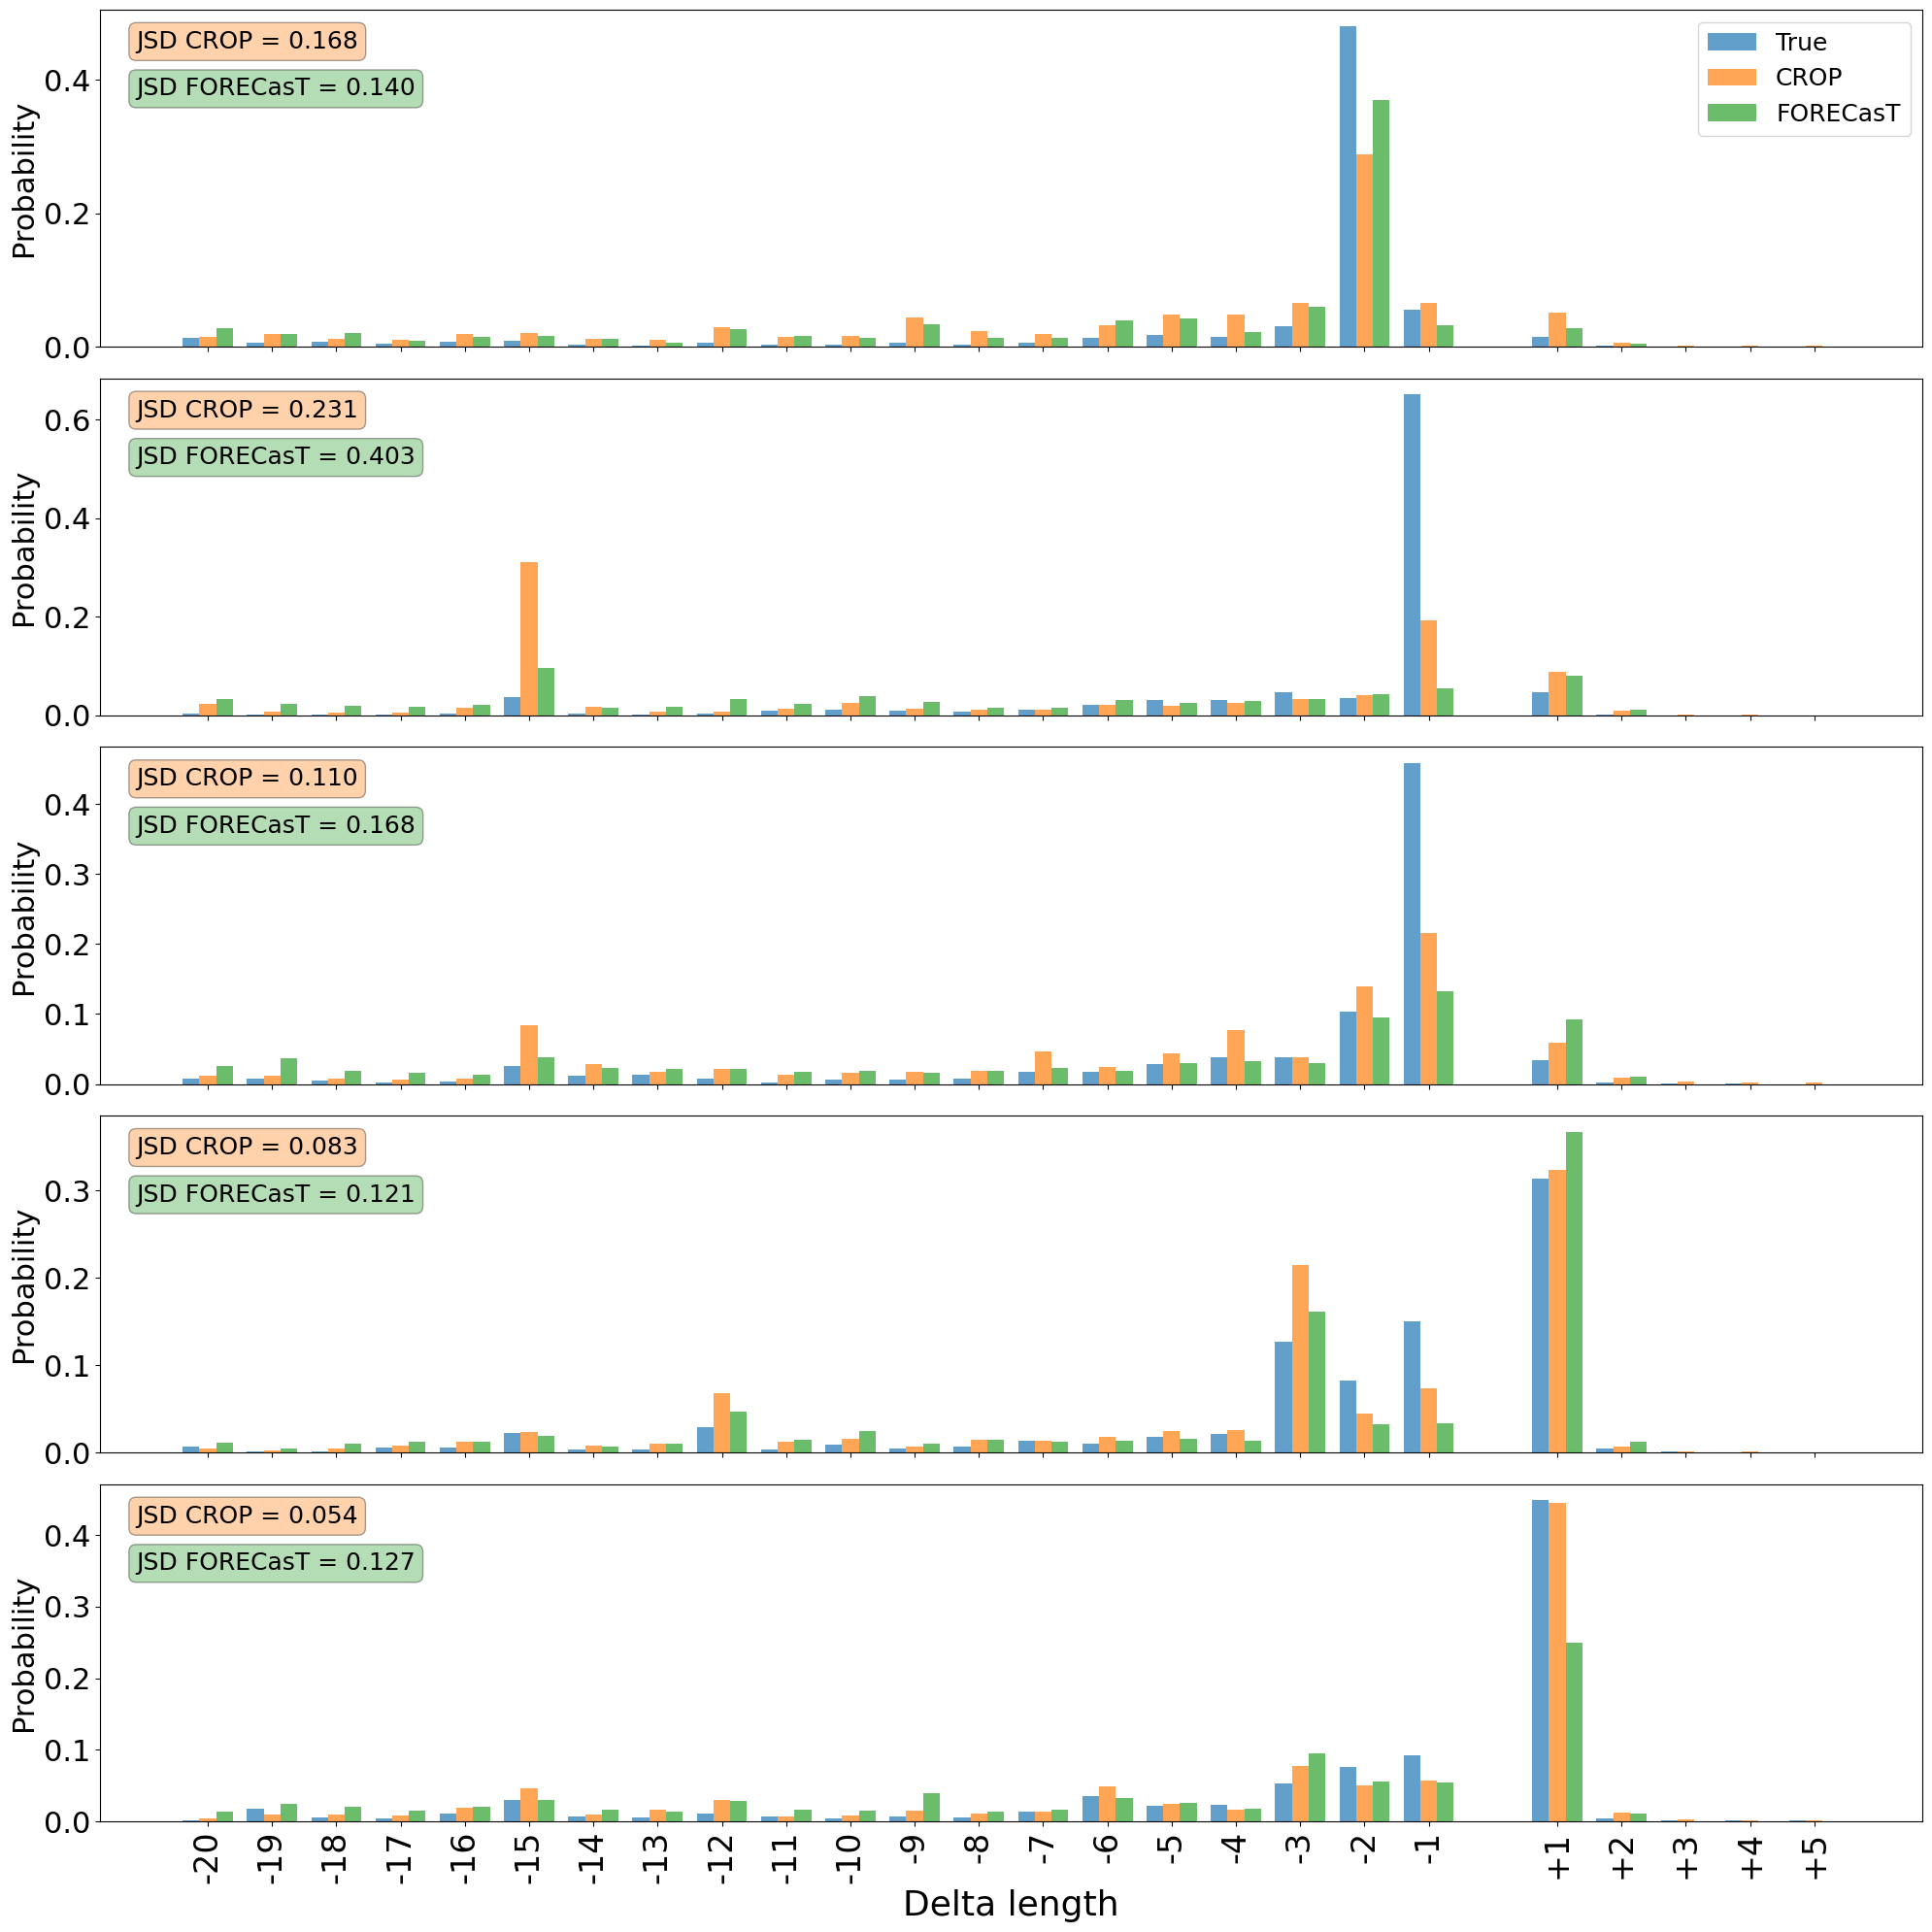

In [1]:
# SPROUT-focused analysis using FORECasT_K562_outcomes predictions
# (Appended cell; does not modify earlier logic/cells.)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sprout_csv_path = "ADL/FORECasT_K562_outcomes.csv"
sprout_df = pd.read_csv(sprout_csv_path)

# Same support alignment logic as above: true deltas are numeric columns, predictions are delta_*
positions = list(range(-70, 21))
sprout_true_cols = [str(p) for p in positions if str(p) in sprout_df.columns]
sprout_pred_cols = [f"delta_{p}" for p in positions if f"delta_{p}" in sprout_df.columns]

if len(sprout_true_cols) == 0 or len(sprout_true_cols) != len(sprout_pred_cols):
    raise ValueError("Could not align SPROUT true/predicted delta-length columns.")

sprout_pos_array = np.array([int(c) for c in sprout_true_cols])


def _jsd(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if p.sum() <= 0 or q.sum() <= 0:
        return np.nan
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    mp = (p > 0) & (m > 0)
    mq = (q > 0) & (m > 0)
    kl_pm = np.sum(p[mp] * np.log2(p[mp] / m[mp]))
    kl_qm = np.sum(q[mq] * np.log2(q[mq] / m[mq]))
    return 0.5 * (kl_pm + kl_qm)


def _normalize(v):
    v = np.asarray(v, dtype=float)
    s = v.sum()
    return v / s if s > 0 else v


# Build FORECasT per-sequence delta distributions using the same parsing logic
# as preprocessing_for_other_tools/FORECasT.ipynb
import os
import re

PREDS_DIR = "../preprocessing_for_other_tools/FORECasT_preds"
MERGED_TXT = os.path.join(PREDS_DIR, "merged.txt")
SUMMARY_TXT = os.path.join(PREDS_DIR, "merged_output_predictedindelsummary.txt")

mapping_df = pd.read_csv(MERGED_TXT, sep="\t")

guide_to_key = {
    row["ID"]: (row["Target"], int(row["PAM Index"]))
    for _, row in mapping_df.iterrows()
}

# Only parse guides relevant to the SPROUT sequence set used here
needed_keys = set(
    zip(
        sprout_df["Target sequence"].astype(str),
        sprout_df["PAM position"].astype(int),
    )
)
needed_guides = {gid for gid, key in guide_to_key.items() if key in needed_keys}

forecast_counts = {}  # key -> {delta_length: count}

with open(SUMMARY_TXT, "r") as f:
    current_guide = None
    current_delta_counts = {}

    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith("@@@"):
            # save previous block
            if current_guide in needed_guides:
                key = guide_to_key[current_guide]
                forecast_counts[key] = current_delta_counts.copy()

            # start new block
            current_guide = line.split("\t")[0].replace("@@@", "")
            current_delta_counts = {}
            continue

        if current_guide not in needed_guides:
            continue

        parts = line.split("\t")
        indel_id = parts[0]
        count = float(parts[2])

        # Skip wildtype/no-change
        if indel_id == "-":
            continue

        matches = re.findall(r"([DI])(\d+)", indel_id)
        delta_length = 0
        for m_type, m_len in matches:
            val = int(m_len)
            delta_length += (-val if m_type == "D" else val)

        current_delta_counts[delta_length] = current_delta_counts.get(delta_length, 0.0) + count

    # save last guide
    if current_guide in needed_guides:
        key = guide_to_key[current_guide]
        forecast_counts[key] = current_delta_counts.copy()


def forecast_distribution_for_key(key, pos_array):
    """Return normalized FORECasT delta distribution on pos_array support."""
    d = forecast_counts.get(key, None)
    if d is None:
        return None
    vec = np.array([d.get(int(p), 0.0) for p in pos_array], dtype=float)
    s = vec.sum()
    if s <= 0:
        return None
    return vec / s


# Per-sequence metrics
sprout_df["read_count_sprout"] = sprout_df[sprout_true_cols].sum(axis=1)

sprout_jsd_crop = []
sprout_jsd_forecast = []
sprout_true_fsr = []
sprout_crop_fsr = []
sprout_forecast_fsr = []

fs_mask = (sprout_pos_array % 3) != 0

for _, row in sprout_df.iterrows():
    key = (str(row["Target sequence"]), int(row["PAM position"]))

    t = row[sprout_true_cols].to_numpy(dtype=float)
    c = row[sprout_pred_cols].to_numpy(dtype=float)

    tn = _normalize(t)
    cn = _normalize(c)
    fn = forecast_distribution_for_key(key, sprout_pos_array)

    sprout_jsd_crop.append(_jsd(tn, cn) if tn.sum() > 0 and cn.sum() > 0 else np.nan)
    sprout_jsd_forecast.append(_jsd(tn, fn) if fn is not None and tn.sum() > 0 else np.nan)

    sprout_true_fsr.append(float(tn[fs_mask].sum()) if tn.sum() > 0 else np.nan)
    sprout_crop_fsr.append(float(cn[fs_mask].sum()) if cn.sum() > 0 else np.nan)
    sprout_forecast_fsr.append(float(fn[fs_mask].sum()) if fn is not None else np.nan)

sprout_df["JSD_SPROUT_CROP"] = sprout_jsd_crop
sprout_df["JSD_SPROUT_FORECAST"] = sprout_jsd_forecast
sprout_df["TRUE_FSR_SPROUT"] = sprout_true_fsr
sprout_df["CROP_FSR_SPROUT"] = sprout_crop_fsr
sprout_df["FORECAST_FSR_SPROUT"] = sprout_forecast_fsr

valid_crop = sprout_df["JSD_SPROUT_CROP"].dropna()
valid_forecast = sprout_df["JSD_SPROUT_FORECAST"].dropna()

print(f"SPROUT rows analyzed (CROP JSD): {len(valid_crop)}")
print(f"SPROUT mean JSD (CROP):          {valid_crop.mean():.6f}")
print(f"SPROUT std JSD (CROP):           {valid_crop.std():.6f}")
print(f"SPROUT rows analyzed (FORECasT): {len(valid_forecast)}")
print(f"SPROUT mean JSD (FORECasT):      {valid_forecast.mean():.6f}")
print(f"SPROUT std JSD (FORECasT):       {valid_forecast.std():.6f}")

# Plot examples in the same style, now with True/CROP/FORECasT
num_examples = 5
plot_mask_sprout = (sprout_pos_array >= -20) & (sprout_pos_array <= 5)
plot_positions_sprout = sprout_pos_array[plot_mask_sprout]
plot_labels_sprout = [(f"+{p}" if p > 0 else str(p)) for p in plot_positions_sprout]

sprout_examples = (
    sprout_df[sprout_df["JSD_SPROUT_CROP"].notna()]
    .sort_values("read_count_sprout", ascending=False)
    .head(num_examples)
)

fig, axes = plt.subplots(num_examples, 1, figsize=(20, 4 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]

for ax in axes:
    ax.set_xticks(plot_positions_sprout)
    ax.set_xticklabels(plot_labels_sprout, rotation=90, fontsize=24)
    ax.tick_params(axis="y", labelsize=22)

# Explicit colors so legend, bars, and JSD boxes match
true_color = "tab:blue"
crop_color = "tab:orange"
forecast_color = "tab:green"

for ax, (_, row) in zip(axes, sprout_examples.iterrows()):
    key = (str(row["Target sequence"]), int(row["PAM position"]))

    t = row[sprout_true_cols].to_numpy(dtype=float)
    c = row[sprout_pred_cols].to_numpy(dtype=float)
    tn = _normalize(t)
    cn = _normalize(c)
    fn = forecast_distribution_for_key(key, sprout_pos_array)

    # If FORECasT distribution is missing for this row, fallback to zeros for plotting
    if fn is None:
        fn = np.zeros_like(tn)

    w = 0.26
    ax.bar(plot_positions_sprout - w, tn[plot_mask_sprout], width=w, label="True", alpha=0.7, color=true_color)
    ax.bar(plot_positions_sprout, cn[plot_mask_sprout], width=w, label="CROP", alpha=0.7, color=crop_color)
    ax.bar(plot_positions_sprout + w, fn[plot_mask_sprout], width=w, label="FORECasT", alpha=0.7, color=forecast_color)

    ax.text(0.02, 0.94, f"JSD CROP = {row['JSD_SPROUT_CROP']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=18,
            bbox=dict(boxstyle="round", facecolor=crop_color, alpha=0.35))
    ax.text(0.02, 0.80, f"JSD FORECasT = {row['JSD_SPROUT_FORECAST']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=18,
            bbox=dict(boxstyle="round", facecolor=forecast_color, alpha=0.35))

    ax.set_ylabel("Probability", fontsize=22)

axes[-1].set_xlabel("Delta length", fontsize=26)
axes[0].legend(fontsize=18)
plt.tight_layout()
plt.savefig("delta_length_distributions_v2.pdf")
plt.show()


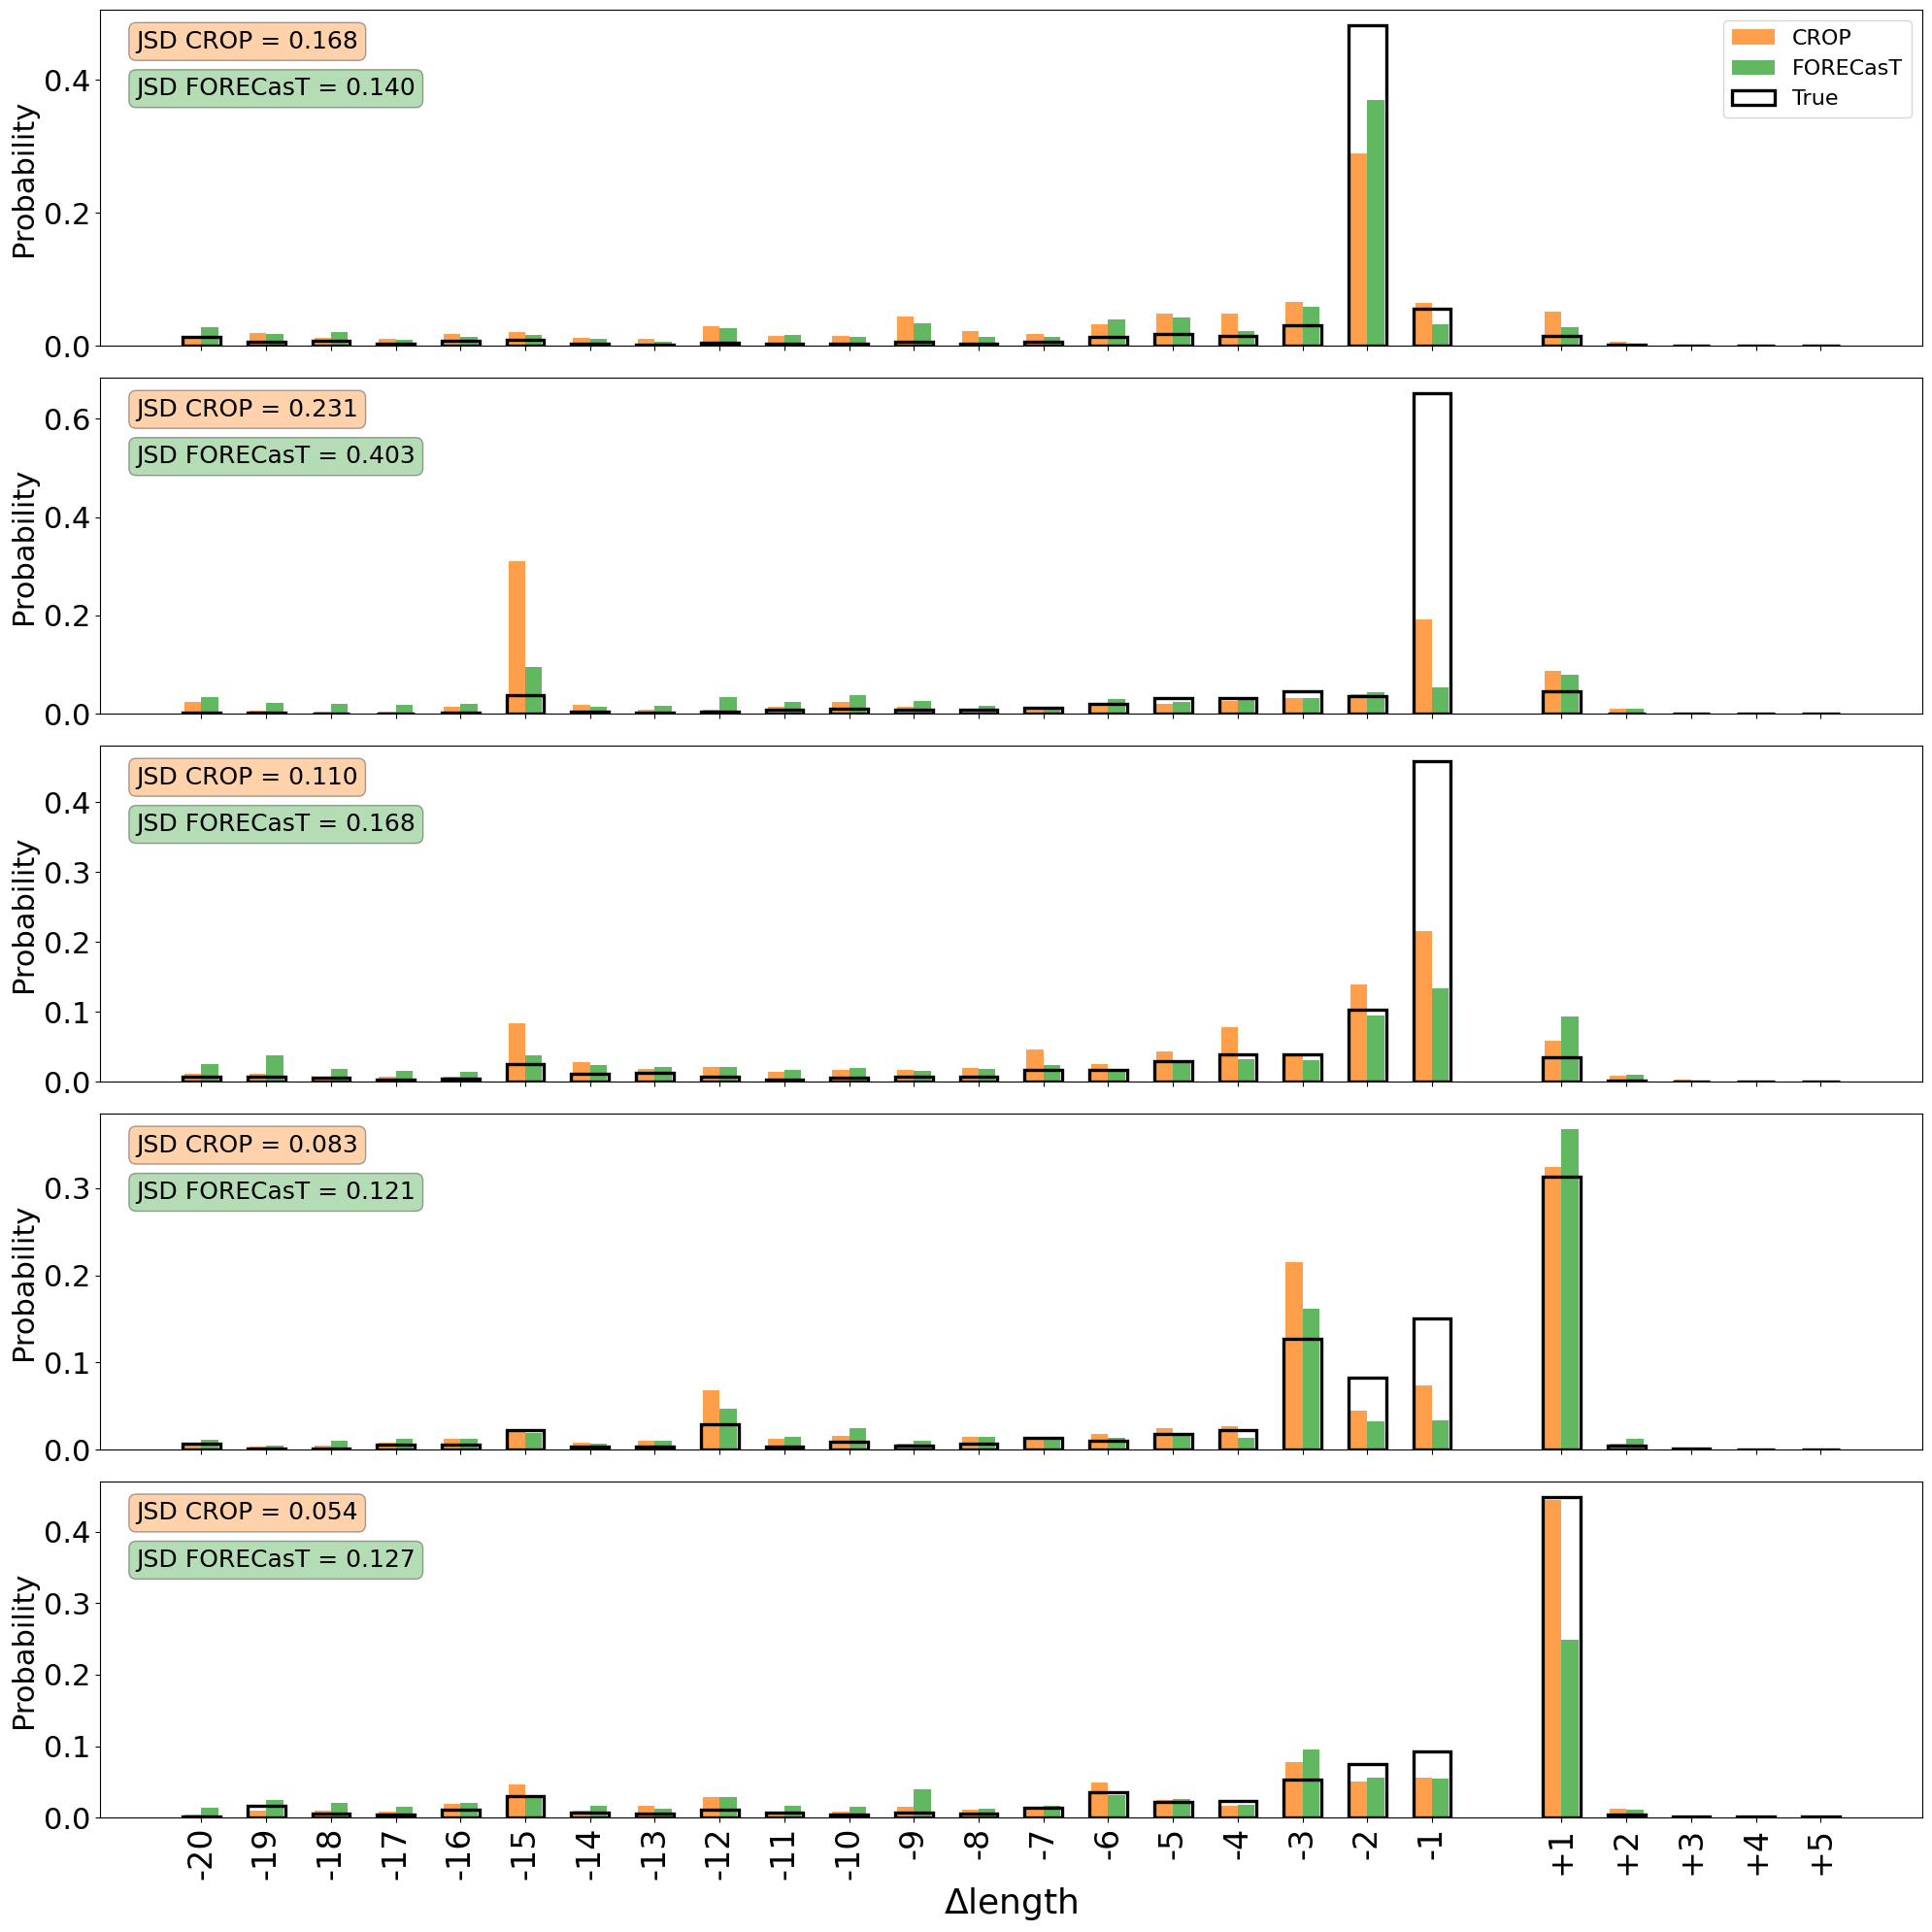

In [4]:
# Variant plot: CROP + FORECasT filled bars, True as spanning outline
# (Requires the previous cell to be run first.)

num_examples_variant = 5
use_log_scale = False  # toggle to True for log-scale probability axis

sprout_examples_variant = (
    sprout_df[sprout_df["JSD_SPROUT_CROP"].notna()]
    .sort_values("read_count_sprout", ascending=False)
    .head(num_examples_variant)
)

fig, axes = plt.subplots(num_examples_variant, 1, figsize=(20, 4 * num_examples_variant), sharex=True)
if num_examples_variant == 1:
    axes = [axes]

for ax in axes:
    ax.set_xticks(plot_positions_sprout)
    ax.set_xticklabels(plot_labels_sprout, rotation=90, fontsize=24)
    ax.tick_params(axis="y", labelsize=22)

for ax, (_, row) in zip(axes, sprout_examples_variant.iterrows()):
    key = (str(row["Target sequence"]), int(row["PAM position"]))

    t = row[sprout_true_cols].to_numpy(dtype=float)
    c = row[sprout_pred_cols].to_numpy(dtype=float)
    tn = _normalize(t)
    cn = _normalize(c)
    fn = forecast_distribution_for_key(key, sprout_pos_array)

    if fn is None:
        fn = np.zeros_like(tn)

    # Two model bars centered around each delta position
    model_w = 0.26
    crop_x = plot_positions_sprout - model_w / 2
    forecast_x = plot_positions_sprout + model_w / 2

    # True outline spans both model bars (+ tiny padding)
    true_span_w = model_w * 2 + 0.06

    # Filled model bars
    ax.bar(crop_x, cn[plot_mask_sprout], width=model_w, label="CROP", alpha=0.75, color="tab:orange")
    ax.bar(forecast_x, fn[plot_mask_sprout], width=model_w, label="FORECasT", alpha=0.75, color="tab:green")

    # True as transparent outline spanning both model bars
    ax.bar(
        plot_positions_sprout,
        tn[plot_mask_sprout],
        width=true_span_w,
        label="True",
        facecolor="none",
        edgecolor="black",
        linewidth=2.4,
        zorder=5,
    )

    ax.text(0.02, 0.94, f"JSD CROP = {row['JSD_SPROUT_CROP']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=18,
            bbox=dict(boxstyle="round", facecolor="tab:orange", alpha=0.35))
    ax.text(0.02, 0.80, f"JSD FORECasT = {row['JSD_SPROUT_FORECAST']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=18,
            bbox=dict(boxstyle="round", facecolor="tab:green", alpha=0.35))

    if use_log_scale:
        ax.set_yscale("log")

    ax.set_ylabel("Probability", fontsize=22)

axes[-1].set_xlabel("$\Delta$length", fontsize=26)
axes[0].legend(fontsize=16, loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("delta_length_distributions_v3.pdf")
plt.show()
